# Notebook-A4 (Data Wrangling-1)

- Linear Regression using Boston Housing dataset
- [Dataset source](https://www.kaggle.com/c/boston-housing)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset into pandas DataFrame
df= pd.read_csv("Assignment-A4-BostonHousing.csv")

In [3]:
# Printing information about the DataFrame
print("Columns:\n", df.columns)
print("Info:\n", df.info())
print("Description:\n", df.describe())

Columns:
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
Info:
 None
Description:
              crim          zn       indus        chas    

In [4]:
# Check for missing values
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


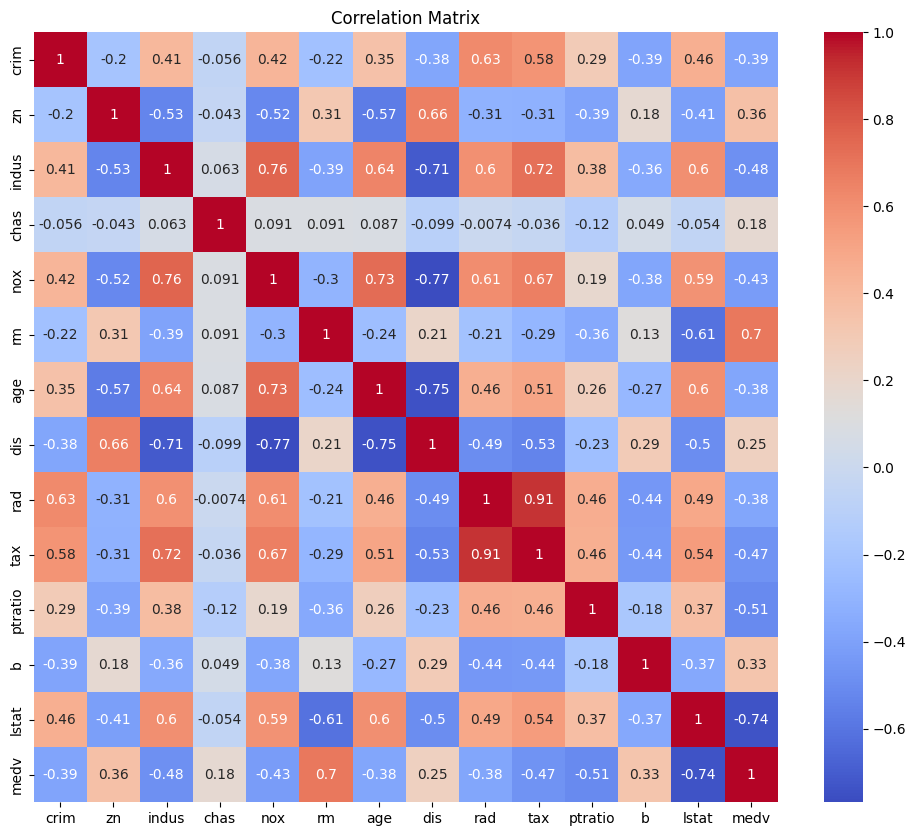

In [5]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [6]:
X = df.drop('medv', axis=1)  # Deleted/Dropped "medv" (median value) column from dataset
y = df['medv']               # Target (Median value of owner-occupied homes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data into 80% training and 20% testing
# X is independent variable; y is dependent variable

In [7]:
lr = LinearRegression() # Create linear regression model object "lr"
lr.fit(X_train, y_train) # Train linear regression model using "X_train" and "y_train"
y_pred = lr.predict(X_test) # Make prediction on test case (X_train); predicated value stored in variable (y_pred)

# Evaluation
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R-squared (R²):", r2_score(y_test, y_pred))

Mean Squared Error (MSE): 24.291119474973478
R-squared (R²): 0.6687594935356326


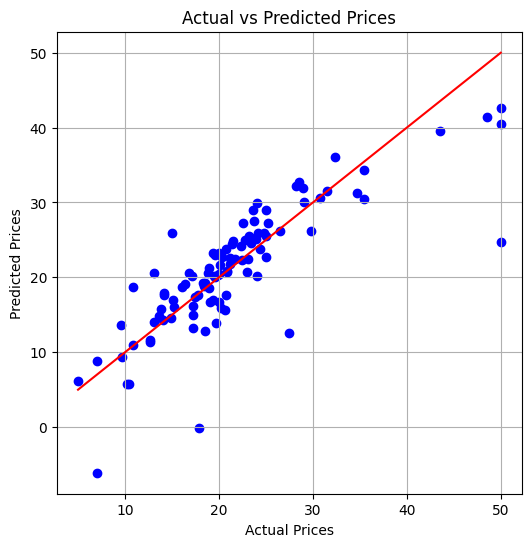

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.grid(True)
plt.show()